<a href="https://colab.research.google.com/github/bcabalic/UCB-MOD5/blob/main/MOD5_PracticalApplication_coupons.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




## DATA EXPLORATION

In [110]:
# Read the CSV
df = pd.read_csv('/content/coupons.csv')

In [111]:
df.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


I'm noticing here, that anything within 15min is also within 5min by default.

2. Investigate the dataset for missing or problematic data.

In [112]:
# Let's see if there is any missing data
df.isnull().sum()


,0
destination,0
passanger,0
weather,0
temperature,0
time,0
coupon,0
expiration,0
gender,0
age,0
maritalStatus,0


I see that there is missing data in car, Bar, CoffeHouse, CarryAway, RestaurantLessThan20, and Restaurant20To50.  Let me analyze how this is relevant. Will I need to exclude or fill in something here?


In [113]:
# Let's sample the columns with missing values NaN
cols = [
    'coupon',
    'car',
    'Bar',
    'CoffeeHouse',
    'CarryAway',
    'RestaurantLessThan20',
    'Restaurant20To50'
]

df[df[cols].isnull().any(axis=1)][cols].sample(20)

,coupon,car,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50
8458,Restaurant(<20),NaN,never,gt8,less1,1~3,less1
3572,Restaurant(20-50),NaN,gt8,1~3,NaN,4~8,less1
7697,Coffee House,NaN,less1,less1,less1,1~3,1~3
12305,Restaurant(<20),NaN,less1,never,1~3,less1,less1
5987,Restaurant(<20),NaN,never,never,4~8,1~3,never
2382,Restaurant(<20),NaN,NaN,NaN,NaN,NaN,NaN
11557,Restaurant(20-50),NaN,1~3,gt8,4~8,1~3,less1
4420,Coffee House,NaN,less1,never,4~8,4~8,never
8766,Carry out & Take away,NaN,1~3,1~3,less1,1~3,less1
11318,Carry out & Take away,NaN,4~8,1~3,gt8,gt8,1~3


We can see above that some columns specifically say they "never" visit that type of establishment.  While some ar Null (NaN).  Is it safe to assume that no answer means "never"?   NaN could also mean decline to give answer.  I'm not sure what to do here yet, I'll come back to it.


In [114]:
# Let's continue investigation
print("\nNumber of rows, columns:")
print(df.shape)


Number of rows, columns:
(12684, 26)


In [115]:
# Let's see the columns
df.columns


Index(['destination', 'passanger', 'weather', 'temperature', 'time', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'car', 'Bar', 'CoffeeHouse',
       'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50',
       'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min',
       'direction_same', 'direction_opp', 'Y'],
      dtype='object')

In [116]:
# How many Unque attributes are there across all columns?
unique_counts = df.nunique(dropna=True)
unique_counts



,0
destination,3
passanger,4
weather,3
temperature,3
time,5
coupon,5
expiration,2
gender,2
age,8
maritalStatus,5


Passenger is misspelled as "Passanger". I will ignore and continue.

In [117]:
# What are total unique counts above? I will subtract 2 for Y column.
unique_counts = df.nunique(dropna=True)

total_unique = unique_counts.sum()
total_unique

np.int64(123)

121 total unique values across 25 columns

In [118]:
# What is in column 'car'?
df['car'].value_counts(dropna=False)

,count
car,
NaN,12576
Scooter and motorcycle,22
Mazda5,22
do not drive,22
crossover,21
Car that is too old to install Onstar :D,21


This seems like irrelevant data. I simply won't use car in any of my analysis.


In [119]:
# Just drop CAR column, and create DF2
df2 = df.drop(columns=['car'])

# I will take a quick peek at some other plots before continuing

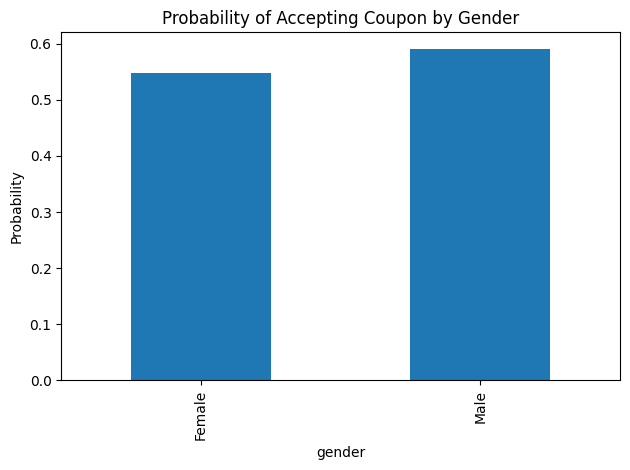

In [129]:
#Let's look by gender

ax = (
    df.groupby('gender')['Y']
      .mean()
      .plot(kind='bar', title='Probability of Accepting Coupon by Gender')
)

ax.set_ylabel('Probability')

plt.tight_layout()
plt.show()


I would have thought females accept coupons more. Let's continue looking for interesting trends.

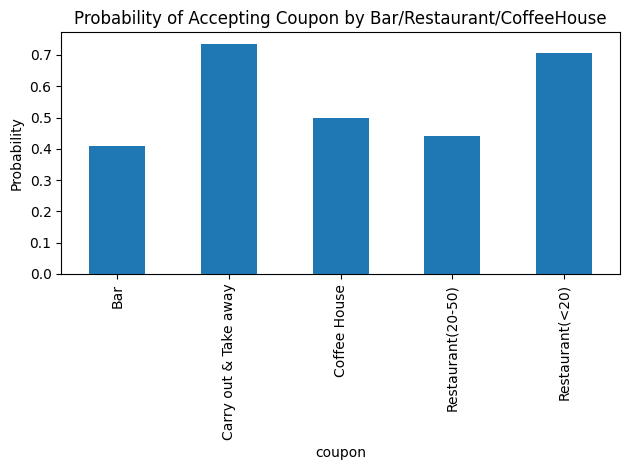

In [131]:
#let's look at probability vs type of coupon

ax = (
    df.groupby('coupon')['Y']
      .mean()
      .plot(
          kind='bar',
          title='Probability of Accepting Coupon by Bar/Restaurant/CoffeeHouse'
      )
)

ax.set_ylabel('Probability')

plt.tight_layout()
plt.show()

This looks a bit more interesting, we can see that if the type of coupon is carry out or a restaurant less than 20min away there is a significantly better probability they will accept the coupon.

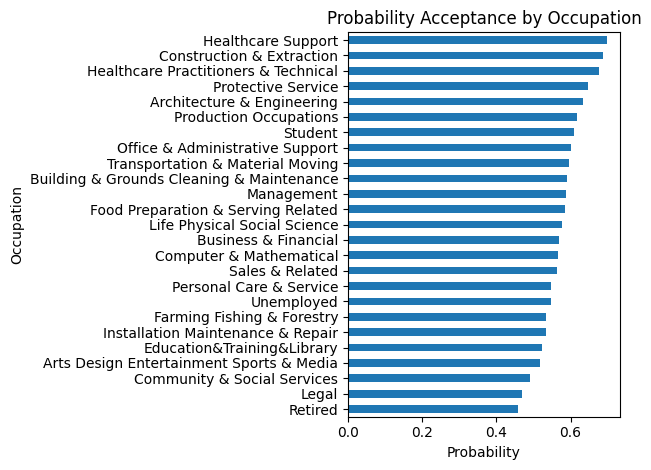

In [134]:
# I wonder if there is any difference by occupation

ax = (
    df.groupby('occupation')['Y']
      .mean()
      .sort_values(ascending=True)   # ⬅ better order for horizontal bars
      .plot(
          kind='barh',
          title='Probability Acceptance by Occupation'
      )
)

ax.set_xlabel('Probability')
ax.set_ylabel('Occupation')

plt.tight_layout()
plt.show()

There's interesting results here. Healthcare related occupation in 2 of top 3.

3. Decide what to do about your missing data -- drop, replace, other...

In [137]:
#What to do about missing data?
cols = [
    'coupon',
    'Bar',
    'CoffeeHouse',
    'CarryAway',
    'RestaurantLessThan20',
    'Restaurant20To50'
]

df[df[cols].isnull().any(axis=1)][cols] \
    .sample(30) \
    .style.hide(axis='index') #hide the index column

coupon,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50
Coffee House,never,nan,less1,less1,never
Restaurant(<20),never,never,less1,never,nan
Restaurant(<20),nan,nan,nan,nan,nan
Coffee House,nan,nan,nan,nan,nan
Carry out & Take away,never,never,nan,4~8,1~3
Bar,never,nan,1~3,1~3,less1
Carry out & Take away,never,never,4~8,nan,never
Bar,never,never,less1,never,nan
Coffee House,nan,1~3,4~8,1~3,1~3
Coffee House,never,never,never,less1,nan


As you can see from the sample above, it DOES NOT make sense to drop any data because any row with dropped data, may still have relevant information as it pertainss to a coupon acceptance.

I can't really replace NaN values because that would cause inccurate results.

I suspect the data was not input. I cannot imply that a "NaN" answer is equal to "never".  

I will just ignore missing data.

4. What proportion of the total observations chose to accept the coupon?



In [15]:
#as a percentage
percentage = (df['Y'] == 1).mean() * 100
percentage

#regular portion, mean:
portion = (df['Y'] == 1).mean()
portion

print(portion)
print(percentage)

0.5684326710816777
56.84326710816777


5. Use a bar plot to visualize the `coupon` column.

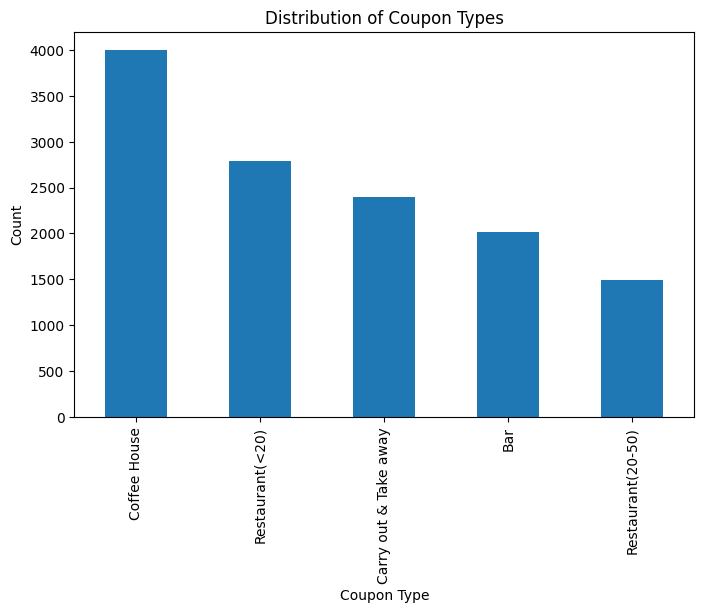

In [11]:
#several above. I'll come back to this.
import matplotlib.pyplot as plt

df['coupon'].value_counts().plot(
    kind='bar',
    title='Distribution of Coupon Types',
    figsize=(8,5)
)

plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.show()

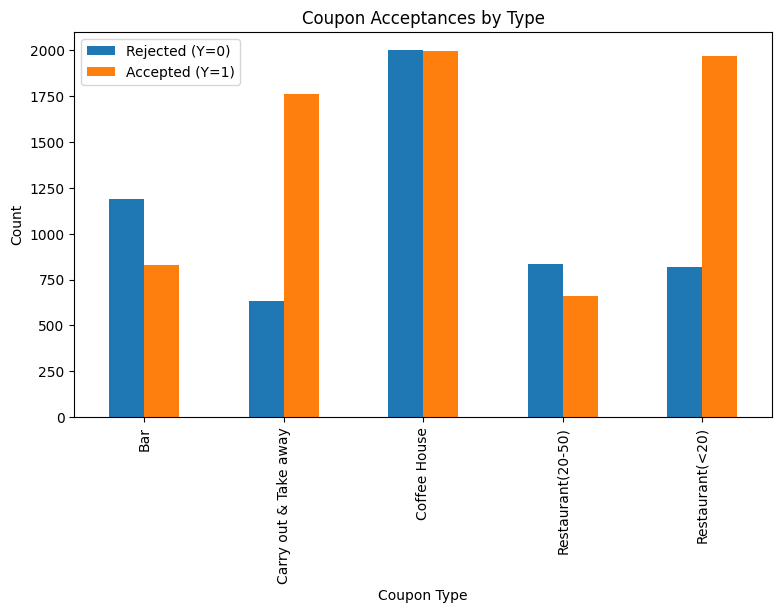

In [139]:
#probability of coupon acceptance by type:
import pandas as pd

pd.crosstab(df['coupon'], df['Y']).plot(
    kind='bar',
    stacked=False,
    figsize=(9,5),
    title='Coupon Acceptances by Type'
)

plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.legend(['Rejected (Y=0)', 'Accepted (Y=1)'])
plt.show()

6. Use a histogram to visualize the temperature column.

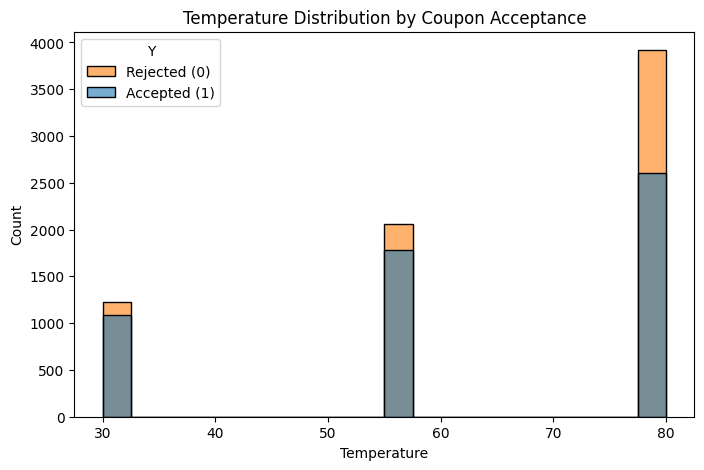

In [138]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='temperature', hue='Y', bins=20, multiple='layer', alpha=0.6)
plt.title('Temperature Distribution by Coupon Acceptance')
plt.xlabel('Temperature')
plt.ylabel('Count')
plt.legend(title='Y', labels=['Rejected (0)', 'Accepted (1)'])
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


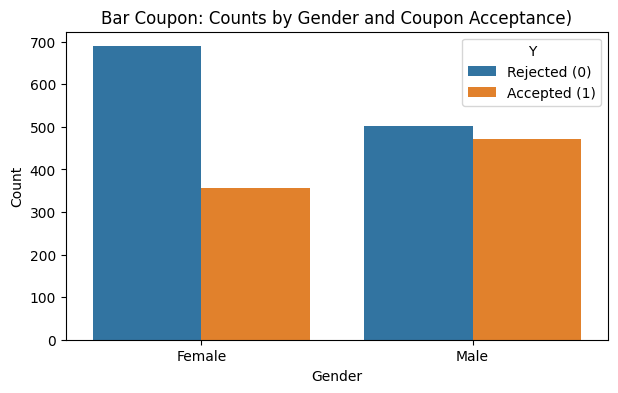

In [140]:
# bar coupons with m/f and Y=0/1
bar_df = df[df['coupon'].eq('Bar')].copy()

plt.figure(figsize=(7,4))
sns.countplot(data=bar_df, x='gender', hue='Y')
plt.title("Bar Coupon: Counts by Gender and Coupon Acceptance)")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Y", labels=["Rejected (0)", "Accepted (1)"])
plt.show()



This is good. Males are more likely to accept a coupon for a bar.

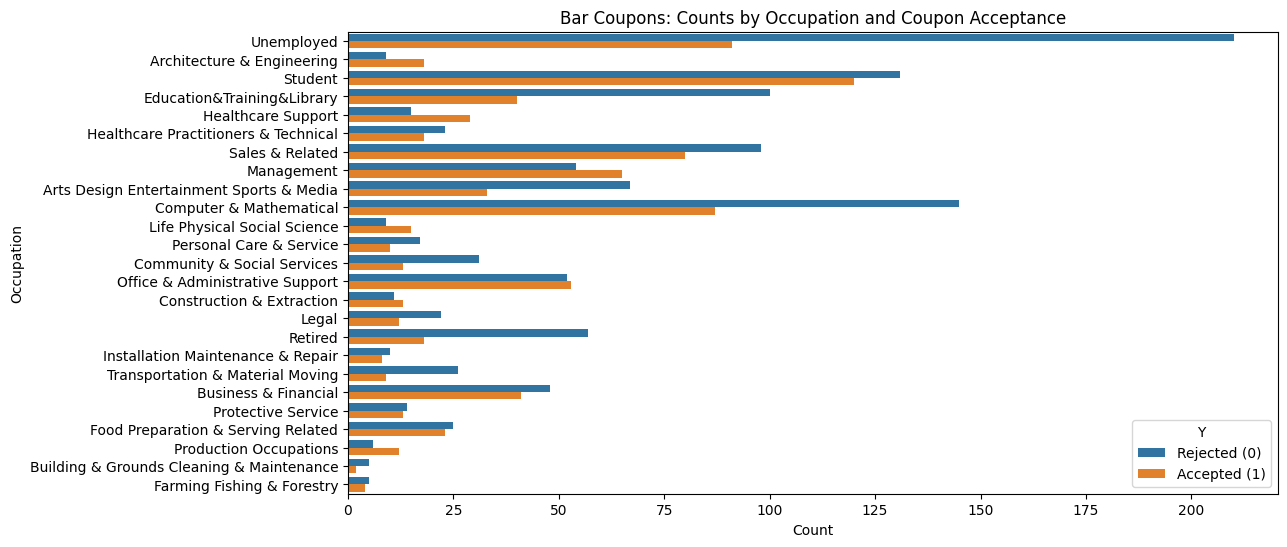

In [142]:
#bar vs occupation
plt.figure(figsize=(12,6))
sns.countplot(
    data=bar_df,
    y='occupation',
    hue='Y'
)
plt.title('Bar Coupons: Counts by Occupation and Coupon Acceptance')
plt.xlabel('Count')
plt.ylabel('Occupation')
plt.legend(title='Y', labels=['Rejected (0)', 'Accepted (1)'])
plt.show()

Interesting also.  Let's continue exploring Bar coupons

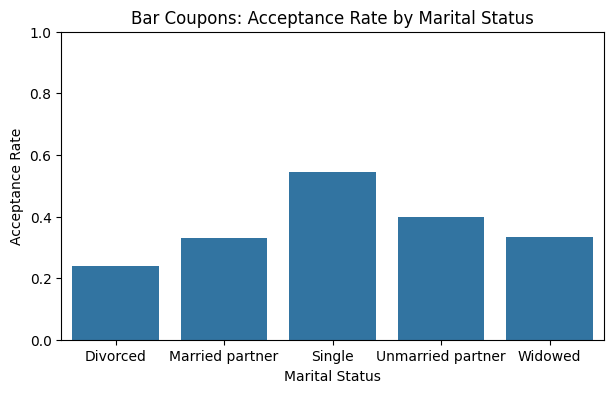

In [144]:
#what about Bar vs Marital Status?
rate = (
    bar_df
    .groupby('maritalStatus')['Y']
    .mean()
    .reset_index()
)

plt.figure(figsize=(7,4))
sns.barplot(
    data=rate,
    x='maritalStatus',
    y='Y'
)

plt.title('Bar Coupons: Acceptance Rate by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Acceptance Rate')
plt.ylim(0,1)
plt.show()

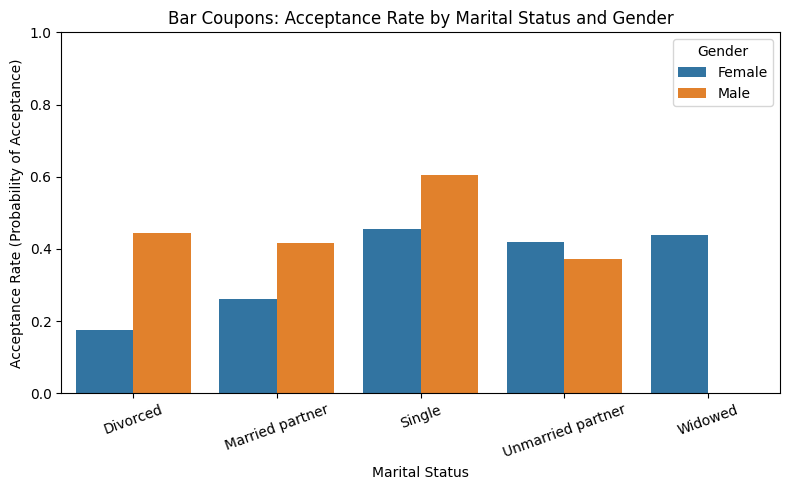

In [146]:
# ok what about marital status and gender with bar coupons


# combination of marital status and gender
rate = (
    bar_df
    .groupby(['maritalStatus', 'gender'])['Y']
    .mean()
    .reset_index()
)

# compare acceptance rates across marital status, split by gender
plt.figure(figsize=(8, 5))
sns.barplot(
    data=rate,
    x='maritalStatus',
    y='Y',
    hue='gender'
)

#chart properties
plt.title('Bar Coupons: Acceptance Rate by Marital Status and Gender')
plt.xlabel('Marital Status')
plt.ylabel('Acceptance Rate (Probability of Acceptance)')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(title='Gender')

#plot
plt.tight_layout()
plt.show()

This is good too.  Let's move on.

2. What proportion of bar coupons were accepted?


In [12]:
# Just use the mean overall
bar_acceptance_rate = df.loc[df['coupon'] == 'Bar', 'Y'].mean()
bar_acceptance_rate


np.float64(0.41001487357461575)

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [147]:
#create the 2 groups
low_bar = ['never', 'less1', '1~3']
high_bar = ['4~8', 'gt8']


#prep
df['bar_freq_group'] = df['Bar'].apply(
    lambda x: '≤3 times/month' if x in low_bar
    else '>3 times/month' if x in high_bar
    else None
)

bar_comp = df.dropna(subset=['bar_freq_group'])

#compute acceptance rates
acceptance_rates = (
    bar_comp
    .groupby('bar_freq_group')['Y']
    .mean()
)

acceptance_rates


bar_stats = (
    bar_comp
    .groupby('bar_freq_group')['Y']
    .agg(Acceptance_Rate='mean', Count='count')
    .reset_index()
)

bar_stats

#Just a quick output is fine


,bar_freq_group,Acceptance_Rate,Count
0,>3 times/month,0.622456,1425
1,≤3 times/month,0.562052,11152


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


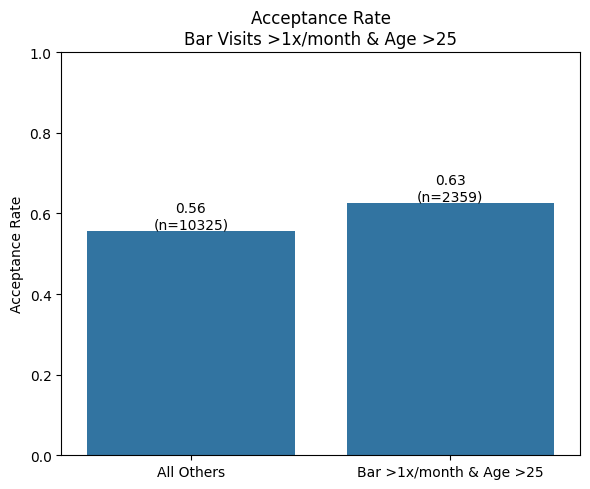

In [148]:
# Define bar-frequency buckets
more_than_once = ['1~3', '4~8', 'gt8']
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['bar_often_over25'] = (
    df['Bar'].isin(more_than_once) &
    (df['age'] > 25)
)

df.groupby('bar_often_over25')['Y'].mean().rename({
    True: 'Bar >1x/month & Age >25',
    False: 'All Others'
})

#compute rates
bar_age_stats = (
    df
    .groupby('bar_often_over25')['Y']
    .agg(Acceptance_Rate='mean', Count='count')
    .rename(index={
        True: 'Bar >1x/month & Age >25',
        False: 'All Others'
    })
    .reset_index()
)

bar_age_stats

#plot
plt.figure(figsize=(6, 5))

ax = sns.barplot(
    data=bar_age_stats,
    x='bar_often_over25',
    y='Acceptance_Rate'
)

ax.set_title('Acceptance Rate\nBar Visits >1x/month & Age >25')
ax.set_xlabel('')
ax.set_ylabel('Acceptance Rate')
ax.set_ylim(0, 1)

#annotate
for i, row in bar_age_stats.iterrows():
    ax.text(
        i,
        row['Acceptance_Rate'],
        f"{row['Acceptance_Rate']:.2f}\n(n={int(row['Count'])})",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [149]:
# Bar frequency > once per month
more_than_once = ['1~3', '4~8', 'gt8']

# Occupations to exclude
excluded_jobs = ['Farming Fishing & Forestry']

df['target_group'] = (
    df['Bar'].isin(more_than_once) &
    (df['passanger'] != 'Kid') &
    (~df['occupation'].isin(excluded_jobs))
)

acceptance_rates = (
    df.groupby('target_group')['Y']
    .mean()
    .rename({
        True: 'Bar >1x/month, No Kid Passenger, Non-FFF Occupation',
        False: 'All Others'
    })
)

acceptance_rates

#Just a quick output is fine


,Y
target_group,
All Others,0.544616
"Bar >1x/month, No Kid Passenger, Non-FFF Occupation",0.622114


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



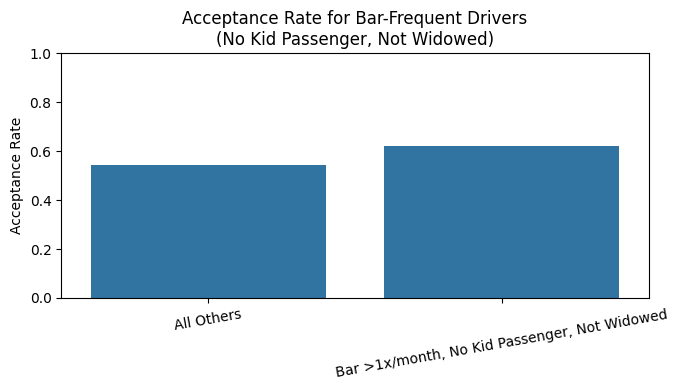

In [150]:
#go to bars more than once a month, had passengers that were not a kid, and were not widowed

#define condition
bar_more_than_once = ['1~3', '4~8', 'gt8']

df['bar_notkid_notwidowed'] = (
    df['Bar'].isin(bar_more_than_once) &
    (df['passanger'] != 'Kid') &
    (df['maritalStatus'] != 'Widowed')
)

#calc accpetance rates
rates = (
    df.groupby('bar_notkid_notwidowed')['Y']
      .mean()
      .reset_index()
)

rates['Group'] = rates['bar_notkid_notwidowed'].map({
    True: 'Bar >1x/month, No Kid Passenger, Not Widowed',
    False: 'All Others'
})

#plot
plt.figure(figsize=(7,4))
sns.barplot(
    data=rates,
    x='Group',
    y='Y',
    errorbar=None
)

plt.title('Acceptance Rate for Bar-Frequent Drivers\n(No Kid Passenger, Not Widowed)')
plt.xlabel('')
plt.ylabel('Acceptance Rate')
plt.ylim(0, 1)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

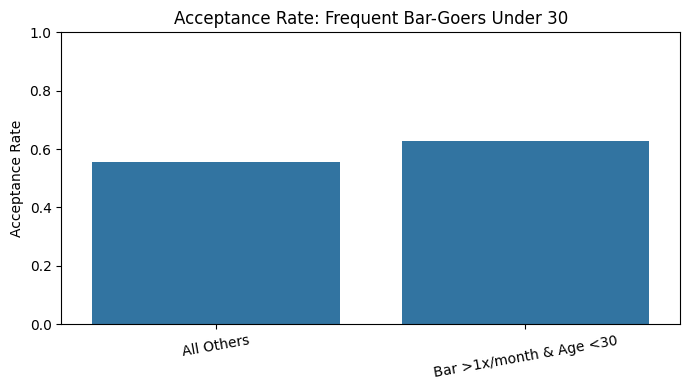

In [151]:
#go to bars more than once a month and are under the age of 30
# Ensure age is numeric
df['age_num'] = pd.to_numeric(df['age'], errors='coerce')

# Bar frequency > once per month
bar_more_than_once = ['1~3', '4~8', 'gt8']

df['bar_often_under30'] = (
    df['Bar'].isin(bar_more_than_once) &
    (df['age_num'] < 30)
)
#compute acceptance rates
rates = (
    df.groupby('bar_often_under30')['Y']
      .mean()
      .reset_index()
)

rates['Group'] = rates['bar_often_under30'].map({
    True: 'Bar >1x/month & Age <30',
    False: 'All Others'
})

#plot acceptance rates
plt.figure(figsize=(7,4))
sns.barplot(
    data=rates,
    x='Group',
    y='Y',
    errorbar=None
)

plt.title('Acceptance Rate: Frequent Bar-Goers Under 30')
plt.xlabel('')
plt.ylabel('Acceptance Rate')
plt.ylim(0, 1)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


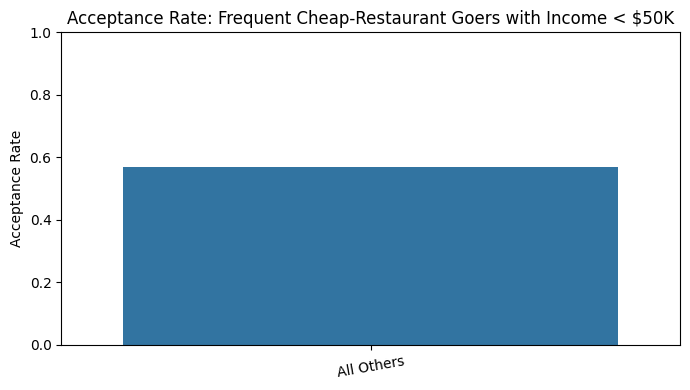

In [152]:
#go to cheap restaurants more than 4 times a month and income is less than 50K

#define

# Convert income safely (e.g., "50K", "Less than $12,500" → numeric)
df['income_num'] = (
    df['income']
    .astype(str)
    .str.extract(r'(\d+)', expand=False)
    .astype(float)
)

# Cheap restaurant frequency > 4 times/month
cheap_rest_often = ['4~8', 'gt8']

df['cheap_rest_low_income'] = (
    df['RestaurantLessThan20'].isin(cheap_rest_often) &
    (df['income_num'] < 50)
)

#compute
rates = (
    df.groupby('cheap_rest_low_income')['Y']
      .mean()
      .reset_index()
)

rates['Group'] = rates['cheap_rest_low_income'].map({
    True: 'Cheap Restaurant >4x/month & Income <50K',
    False: 'All Others'
})

#plot
plt.figure(figsize=(7,4))
sns.barplot(
    data=rates,
    x='Group',
    y='Y',
    errorbar=None
)

plt.title('Acceptance Rate: Frequent Cheap-Restaurant Goers with Income < $50K')
plt.xlabel('')
plt.ylabel('Acceptance Rate')
plt.ylim(0, 1)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


So there were 0 customers that fit this combined category?

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

To be honest, I didn't really find anything interesting in the above charts. In my opinion there wasn't anything too signficant with the above findings.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

#MAIN EXPLORATIONS

In [155]:
# OVERALL VIEW
# Let's just see the top 30 categories w/ the best acceptance rates, minus the CAR column

# drop the CAR column
df2 = df.drop(columns=['car'])


results = []

for col in df2.select_dtypes(include='object').columns:
    stats = (
        df2.groupby(col)['Y']
          .agg(Acceptance_Rate='mean', Count='count')
          .dropna()
    )

    for value, row in stats.iterrows():
        results.append({
            'Column': col,
            'Category': value,
            'Acceptance_Rate': row['Acceptance_Rate'],
            'Count': row['Count']
        })

ranked_categories = (
    pd.DataFrame(results)
    .sort_values('Acceptance_Rate', ascending=False)
)

ranked_categories['Count'] = ranked_categories['Count'].astype(int) #drop the decimals
ranked_categories.head(30).style.hide(axis='index') #Hide the index column

Column,Category,Acceptance_Rate,Count
coupon,Carry out & Take away,0.735478,2393
education,Some High School,0.715909,88
coupon,Restaurant(<20),0.707107,2786
occupation,Healthcare Support,0.698347,242
occupation,Construction & Extraction,0.688312,154
occupation,Healthcare Practitioners & Technical,0.676230,244
passanger,Friend(s),0.673438,3298
Restaurant20To50,gt8,0.662879,264
time,2PM,0.661523,2009
Restaurant20To50,4~8,0.655220,728


These are my basic findings which I can expand upon.  I will attempt to combine conditions that lead to even higher acceptance rates.  In otherwords, within the conditions where the acceptance rate is already high (top 20) I will see if any can be combined to yield a higher acceptance rate.

#1. Let's look at Coupon Acceptance if Restaurant < 20 min\nWith or Without Friends

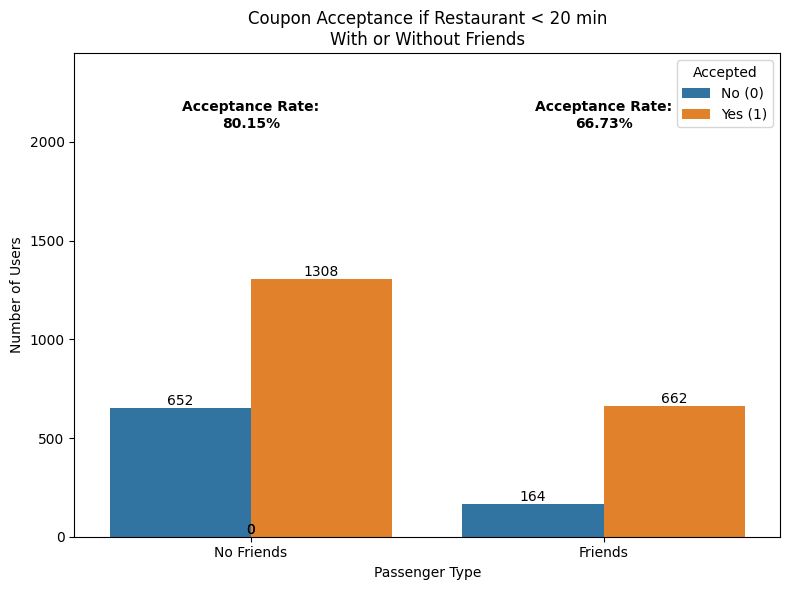

In [161]:
#seaborn plot

#prepare data
rest_df = df[df['coupon'] == 'Restaurant(<20)'].copy()

rest_df.loc[:, 'friends_or_not'] = np.where(
    rest_df['passanger'] == 'Friend(s)',
    'Friends',
    'No Friends'
)

#comput acceptance rate
counts = (
    rest_df
    .groupby(['friends_or_not', 'Y'])
    .size()
    .unstack(fill_value=0)
)

acceptance_rate_pct = (
    counts[1] / (counts[0] + counts[1]) * 100
).round(2)

#seaborn plot
plt.figure(figsize=(8, 6))

ax = sns.countplot(
    data=rest_df,
    x='friends_or_not',
    hue='Y'
)

ax.set_title('Coupon Acceptance if Restaurant < 20 min\nWith or Without Friends')
ax.set_xlabel('Passenger Type')
ax.set_ylabel('Number of Users')

ax.legend(title='Accepted', labels=['No (0)', 'Yes (1)'])

#annotate
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom'
    )

#annotate
y_max = rest_df.groupby('friends_or_not').size().max()

for i, grp in enumerate(acceptance_rate_pct.index):
    ax.text(
        i,
        y_max * 1.05,
        f'Acceptance Rate:\n{acceptance_rate_pct.loc[grp]:.2f}%',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

ax.set_ylim(0, y_max * 1.25)  # headroom so text doesn't clip

#final
plt.tight_layout()
plt.show()


#FINDING 1

In the first analysis, we see that if the restaurant is less than 20 min away the acceptance rate is **70.71%**.  

However **if they are travelling with friends the acceptance rate goes up to 80.15%**!  
Without friends, the acceptance rate is stil high: 66.73%

If sent a coupon for a restaurant within 20 miles, **a group of friends travelling together are 13.42% more likely to accept the coupon than somone travelling solo.** <br>

This condition is also **9.44% higher** than the general average of coupons accepted for restaurants within 20min


#2. Let's look at Acceptance Rate by Coupon Type and Marital Status = Single

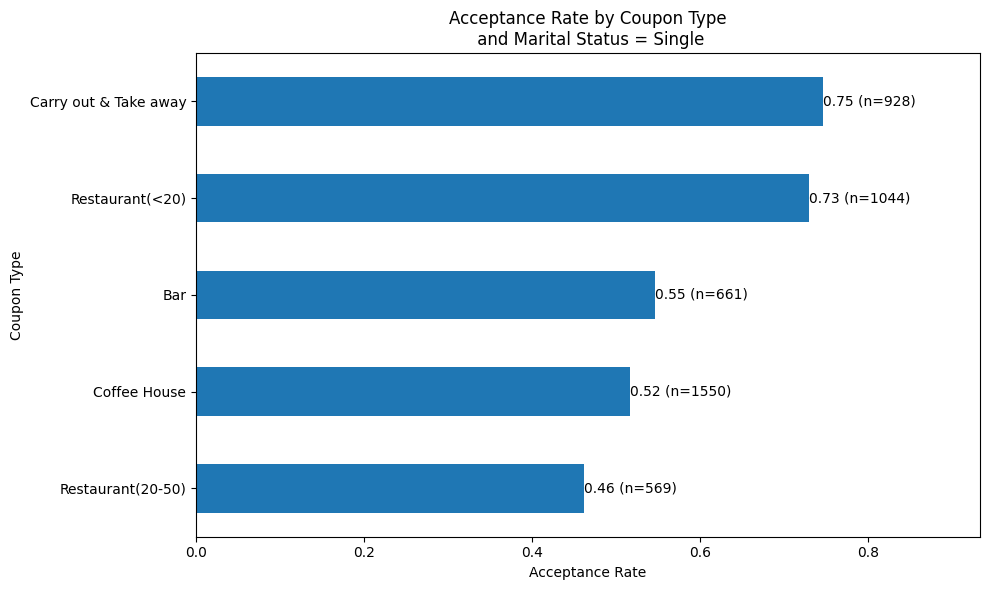

In [160]:
# Let's try something else. Single people have a high acceptance rate and big sample.
# Is there a type of coupon that has a more effective acceptance rate in this category?

#filter first
single_df = df[df['maritalStatus'] == 'Single']

#now grab all coupon values
coupon_acceptance_single = (
    single_df
    .groupby('coupon')['Y']
    .mean()
    .sort_values(ascending=False)
)

coupon_acceptance_single

#add counts
coupon_stats_single = (
    single_df
    .groupby('coupon')['Y']
    .agg(Acceptance_Rate='mean', Count='count')
    .sort_values('Acceptance_Rate', ascending=False)
)

coupon_stats_single

# plot (horizontal)
fig, ax = plt.subplots(figsize=(10, 6))  # wider + taller

coupon_stats_single['Acceptance_Rate'] \
    .sort_values(ascending=True) \
    .plot(kind='barh', ax=ax)

ax.set_title('Acceptance Rate by Coupon Type\n and Marital Status = Single')
ax.set_xlabel('Acceptance Rate')
ax.set_ylabel('Coupon Type')

# annotate bars with rate + count
for p, count in zip(ax.patches, coupon_stats_single.loc[
        coupon_stats_single['Acceptance_Rate']
        .sort_values(ascending=True)
        .index, 'Count']):
    ax.annotate(
        f'{p.get_width():.2f} (n={int(count)})',
        (p.get_width(), p.get_y() + p.get_height() / 2),
        va='center',
        ha='left'
    )

# add some right padding so text doesn't get cut off
ax.set_xlim(0, coupon_stats_single['Acceptance_Rate'].max() * 1.25)

plt.tight_layout()
plt.show()


#FINDING 2

We see above that the coupon acceptance rate for single people is 60.6% overall.  **However, if the coupon is for CarryOut/TakeAway or a Restaurant < 20min away the acceptance rates jump to 75% and 73% respectively!** That's a significant increase! Moreoever, we see here that all other types of coupons yield a slightly lower acceptance rate than the mean of single people in general.

#3. Let's look at Top 15 Categories for 10am coupons expiring in 1 day and highlight the TOP 3 by Count

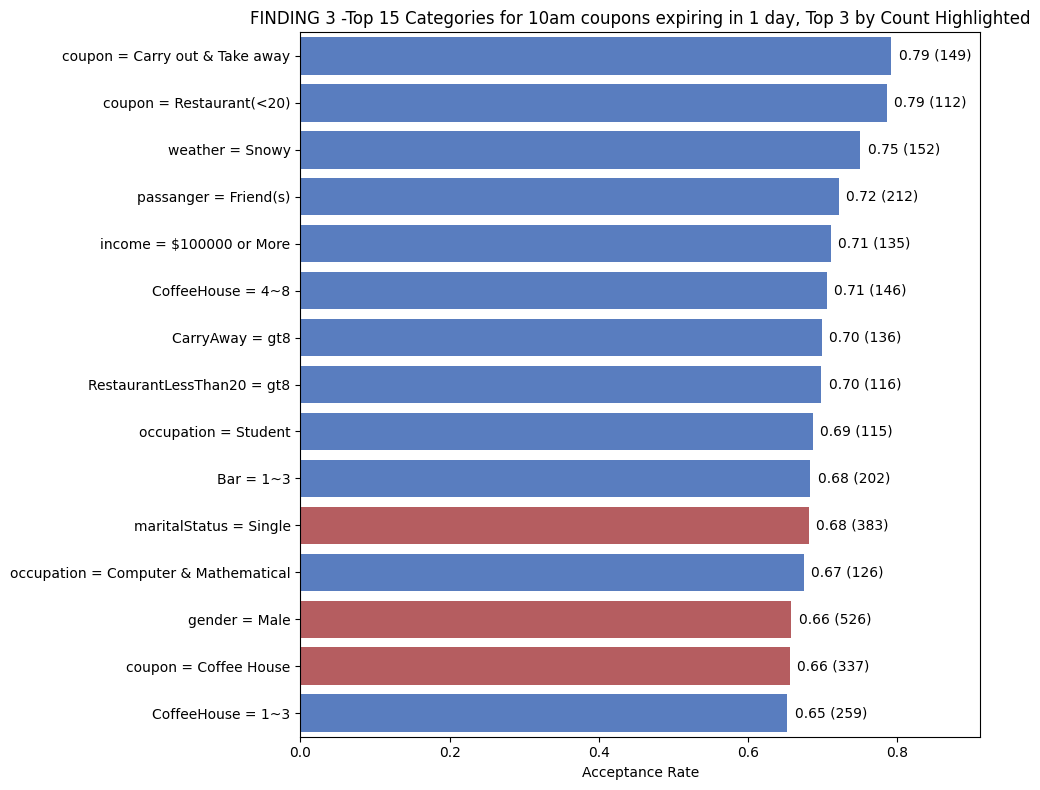

In [124]:
# Let's try to find more high yielding coupon combinations, one with 3 conditions but still a high sample set anything over 100
# For time = 10am and expiry=1d

#filter first
df_10am_1d = df2[
    (df2['time'] == '10AM') &
    (df2['expiration'] == '1d')
].copy()

#filter acceptance rates
results = []

for col in df_10am_1d.select_dtypes(include='object').columns:
    stats = (
        df_10am_1d
        .groupby(col, observed=True)['Y']
        .agg(Acceptance_Rate='mean', Count='count')
        .dropna()
    )

    for value, row in stats.iterrows():
        results.append({
            'Column': col,
            'Category': value,
            'Acceptance_Rate': row['Acceptance_Rate'],
            'Count': row['Count']
        })

#rank them

ranked_10am_1d = (
    pd.DataFrame(results)
    .query('Count >= 100')   # drop any row with less than 100 count
    .sort_values('Acceptance_Rate', ascending=False)
    .reset_index(drop=True)
)

ranked_10am_1d['Count'] = ranked_10am_1d['Count'].astype(int) #drop the decimals
ranked_10am_1d.head(15).style.hide(axis='index') #Hide the index column


# now lets plot these results

top_n = 15

plot_df = (
    ranked_10am_1d
    .sort_values('Acceptance_Rate', ascending=False)  # ⬅ primary sort
    .head(top_n)
    .copy()
)

plot_df['Label'] = plot_df['Column'] + ' = ' + plot_df['Category'].astype(str)

#id top 3 by count
top3_counts = plot_df.nlargest(3, 'Count').index
plot_df['Top3_Count'] = plot_df.index.isin(top3_counts)

#color pallette
base_color = sns.color_palette("muted")[0]
highlight_color = sns.color_palette("deep")[3]

palette = {
    label: (highlight_color if is_top else base_color)
    for label, is_top in zip(plot_df['Label'], plot_df['Top3_Count'])
}


#sorted plot by acceptance rate
plt.figure(figsize=(10, 8))

ax = sns.barplot(
    data=plot_df,
    x='Acceptance_Rate',
    y='Label',
    hue='Label',          # required for palette
    palette=palette,
    legend=False          # prevent duplicate legend
)

ax.set_title(
    'Top 15 Categories for 10am coupons expiring in 1 day, Top 3 by Count Highlighted'
)
ax.set_xlabel('Acceptance Rate')
ax.set_ylabel('')

#annotate
for i, row in plot_df.iterrows():
    ax.text(
        row['Acceptance_Rate'] + 0.01,
        plot_df.index.get_loc(i),
        f"{row['Acceptance_Rate']:.2f} ({int(row['Count'])})",
        va='center'
    )

plt.xlim(0, plot_df['Acceptance_Rate'].max() * 1.15)
plt.tight_layout()
plt.show()



# FINDING 3
This is sorted by acceptance rate and the TOP 3 counts are highlighted.

If you're sending out a coupon at 10am with an 1d expiration - target these individuals (highest sample count in this set) which have shown 65%+ acceptance rate historically:

1. Males
2. Single people
3. Coffee coupons (will also attract customers that have been to a CoffeeHouse 1-8 times!)

#4. Let's look at Passenger type, weather and acceptance rate

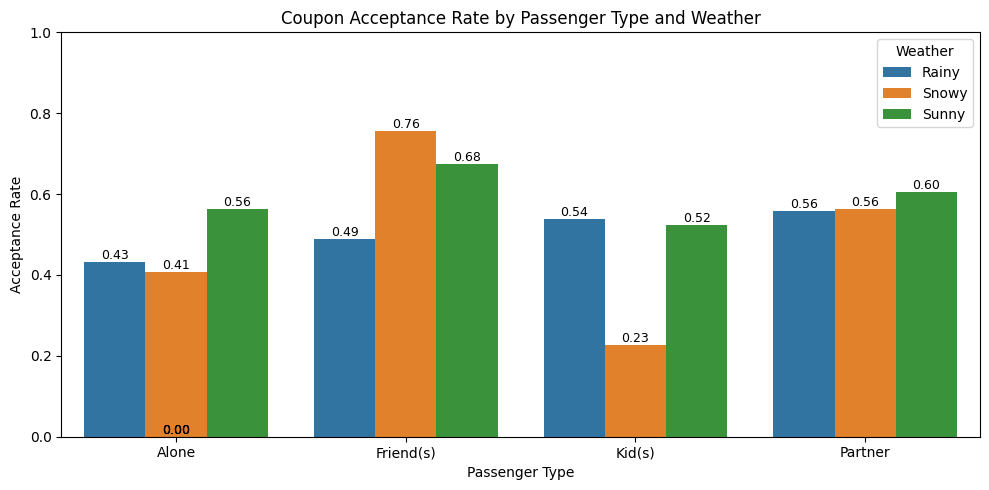

In [153]:
#lets try something with passanger type weather and accpetance rate:

#filter
rate = (
    df.groupby(['passanger', 'weather'])['Y']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=rate,
    x='passanger',
    y='Y',
    hue='weather',
    errorbar=None
)

ax.set_title('Coupon Acceptance Rate by Passenger Type and Weather')
ax.set_xlabel('Passenger Type')
ax.set_ylabel('Acceptance Rate')
ax.set_ylim(0, 1)
ax.legend(title='Weather')

#annotate acceptance rate on each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:.2f}',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()


#FINDING 4
We see above that bad weather (rain or snow) mostly results in a lower coupon acceptance rate.  The one thing that stands out is that when it snows, drivers travelling with friends have a **76%** acceptance rate, I find that abnormally high. We also see that seems to be a correlation between having a companion (Friend or Partner) in incliment weather vs being alone or with kids.

Seeing that snowy weather had the lowest acceptance rate, I wonder what type of coupons had the best acceptance rate when snowing?

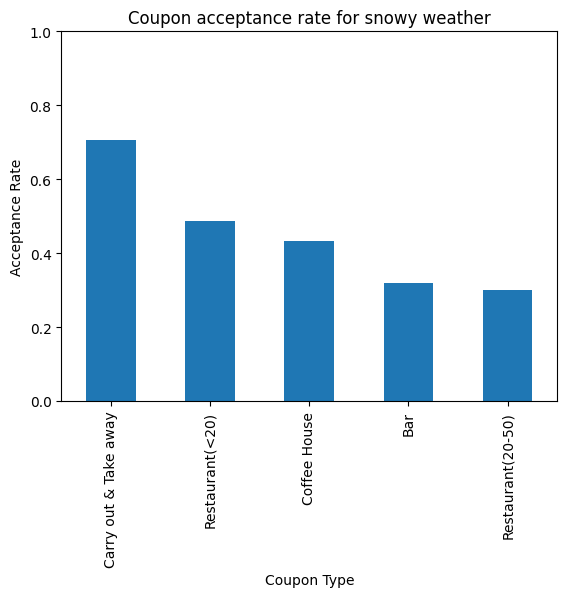

In [154]:
#best coupons for snowy weather

snowy_acceptance = (
    df[df['weather'] == 'Snowy']
    .groupby('coupon')['Y']
    .mean()
    .sort_values(ascending=False)
)

snowy_acceptance.plot(kind='bar')

plt.title('Coupon acceptance rate for snowy weather')
plt.xlabel('Coupon Type')
plt.ylabel('Acceptance Rate')
plt.ylim(0, 1)
plt.show()


Very good find